In [2]:
import pandas as pd
import os

In [18]:
df = pd.read_csv("01_people.csv")
print(df.head())

   person_id                                               name email phone  \
0          1                             Database Administrator   NaN   NaN   
1          2                             Database Administrator   NaN   NaN   
2          3                      Oracle Database Administrator   NaN   NaN   
3          4  Amazon Redshift Administrator and ETL Develope...   NaN   NaN   
4          5             Scrum Master Scrum Master Scrum Master   NaN   NaN   

  linkedin  
0      NaN  
1      NaN  
2      NaN  
3      NaN  
4      NaN  


In [19]:
df = df.drop_duplicates()
print("Removed duplicate rows")


Removed duplicate rows


In [20]:
print(df.isnull().sum())  # Shows missing values per column


person_id        0
name           114
email        53340
phone        53100
linkedin     46395
dtype: int64


In [21]:
df = df.dropna(subset=["name"])
print("Dropped rows where 'name' was missing")

Dropped rows where 'name' was missing


In [22]:
df = df.drop(columns=["email", "phone"])
print("Dropped 'email' and 'phone' columns due to high missing values")

Dropped 'email' and 'phone' columns due to high missing values


In [23]:
df["linkedin"] = df["linkedin"].fillna("Not Available")
print("Filled missing values in 'linkedin' column with 'Not Available'")


Filled missing values in 'linkedin' column with 'Not Available'


In [24]:
print(df.isnull().sum())  # Should print 0 missing values now


person_id    0
name         0
linkedin     0
dtype: int64


In [25]:
df["name"] = df["name"].str.strip().str.lower()
df["linkedin"] = df["linkedin"].str.strip().str.lower()
print("Standardized text formatting (lowercase & trimmed spaces)")


Standardized text formatting (lowercase & trimmed spaces)


In [26]:
df.to_csv("cleaned_01_people.csv", index=False)
print("Cleaned data saved as 'cleaned_01_people.csv'")


Cleaned data saved as 'cleaned_01_people.csv'


2ND FILE

In [27]:
df_abilities = pd.read_csv("02_abilities.csv")
print(df_abilities.head())

   person_id                           ability
0          1  Installation and Building Server
1          1                   Running Backups
2          1   Recovering and Restoring Models
3          1     Support various MS SQL Server
4          1           MS SQL Server 2005/2008


In [28]:
df_abilities = df_abilities.drop_duplicates()
print("Removed duplicate rows")
print(df_abilities.isnull().sum())

Removed duplicate rows
person_id    0
ability      0
dtype: int64


In [29]:
df_abilities.to_csv("cleaned_02_abilities.csv", index=False)
print("Cleaned data saved as 'cleaned_02_abilities.csv'")

Cleaned data saved as 'cleaned_02_abilities.csv'


3RD FILE

In [30]:
df_edu = pd.read_csv("03_education.csv")
print(df_edu.head())

   person_id                       institution  \
0          1              Lead City University   
1          2            lagos state university   
2          3   JNTU - Kakinada, Andhra Pradesh   
3          4         University of Informatics   
4          5  Virginia Commomwealth University   

                                             program start_date  \
0                                Bachelor of Science    07/2013   
1                            bsc in computer science        NaN   
2  Master of Computer Applications in Science and...       2013   
3                       Bachelor in Computer Science      06/07   
4                                                NaN    08/2013   

                   location  
0                       NaN  
1                 Lagos, GU  
2  Kakinada, Andhra Pradesh  
3                 June 2007  
4              Richmond, VA  


In [31]:
print(df_edu.isnull().sum())


person_id          0
institution     1569
program         7761
start_date     21129
location       23256
dtype: int64


In [32]:
df_edu = df_edu.fillna({
    "institution": "Unknown Institution",
    "program": "Unknown Program",
    "start_date": "Not Available",
    "location": "Unknown Location"
})


In [33]:
df_edu["institution"] = df_edu["institution"].str.strip().str.lower()
df_edu["program"] = df_edu["program"].str.strip().str.lower()
df_edu["location"] = df_edu["location"].str.strip().str.lower()

print("Standardized text formatting (lowercase & trimmed spaces).")


Standardized text formatting (lowercase & trimmed spaces).


In [34]:
df_edu = df_edu.drop_duplicates()
print(f"Duplicates removed. New shape: {df_edu.shape}")

Duplicates removed. New shape: (75948, 5)


In [35]:
df_edu.to_csv("cleaned_03_education.csv", index=False)
print("Cleaned education data saved successfully!")


Cleaned education data saved successfully!


4TH FILE

In [36]:
df_exp = pd.read_csv("04_experience.csv", engine="python", on_bad_lines="skip")
print(df_exp.head())

   person_id                          title                       firm  \
0          1         Database Administrator    Family Private Care LLC   
1          1         Database Administrator                     Incomm   
2          2         Database Administrator  Intercontinental Registry   
3          3  Oracle Database Administrator                  Cognizant   
4          3  Oracle Database Administrator                  Convergys   

  start_date end_date              location  
0    04/2017  Present           Roswell, GA  
1    01/2014  02/2017        Alpharetta, GA  
2    12/2008  08/2011             Lagos, GU  
3    06/2016  Present  Hyderabad, Telangana  
4    06/2014  06/2016  Hyderabad, Telangana  


In [37]:
print(f"Rows in dataset: {df_exp.shape[0]}")


Rows in dataset: 265404


In [38]:
with open("04_experience.csv", "r", encoding="utf-8") as f:
    total_lines = sum(1 for _ in f)

skipped_lines = total_lines - df_exp.shape[0]
print(f"⚠️ Skipped {skipped_lines} problematic rows")


⚠️ Skipped 1 problematic rows


In [39]:
print(df_exp.isnull().sum())  # Count missing values per column


person_id         0
title           111
firm           4203
start_date     2262
end_date       2724
location      53055
dtype: int64


In [40]:
df_exp.loc[:, "title"] = df_exp["title"].fillna("Unknown Title")
df_exp.loc[:, "firm"] = df_exp["firm"].fillna("Unknown Firm")
df_exp.loc[:, "start_date"] = df_exp["start_date"].fillna("Not Available")
df_exp.loc[:, "end_date"] = df_exp["end_date"].fillna("Not Available")
df_exp.loc[:, "location"] = df_exp["location"].fillna("Unknown Location")

print("Missing values filled successfully, without warnings!")


Missing values filled successfully, without warnings!


In [41]:
df_exp["title"] = df_exp["title"].str.strip().str.lower()
df_exp["firm"] = df_exp["firm"].str.strip().str.lower()
df_exp["location"] = df_exp["location"].str.strip().str.lower()

print("✅ Standardized text formatting (lowercase & trimmed spaces).")


✅ Standardized text formatting (lowercase & trimmed spaces).


In [42]:
# Check for duplicate rows
duplicates = df_exp.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

# Remove duplicate rows
df_exp.drop_duplicates(inplace=True)

print("Duplicate rows removed successfully!")


Duplicate rows found: 51
Duplicate rows removed successfully!


In [43]:
df_exp["start_date"] = pd.to_datetime(df_exp["start_date"], format="%Y-%m-%d", errors="coerce")
df_exp["end_date"] = pd.to_datetime(df_exp["end_date"], format="%Y-%m-%d", errors="coerce")

print("Dates standardized successfully with explicit format!")


Dates standardized successfully with explicit format!


In [44]:
df_exp.to_csv("cleaned_04_experience.csv", index=False)
print("Cleaned experience dataset saved successfully!")


Cleaned experience dataset saved successfully!


5TH FILE

In [45]:
df_skills = pd.read_csv("05_person_skills.csv", engine="python", on_bad_lines="skip")
print(df_skills.head())

   person_id                    skill
0          1  Database administration
1          1                 Database
2          1            Ms sql server
3          1       Ms sql server 2005
4          1               Sql server


In [46]:
print(df_skills.isnull().sum())  # Count missing values in each column


person_id    0
skill        9
dtype: int64


In [47]:
df_skills = df_skills.assign(skill=df_skills["skill"].fillna("Unknown Skill"))


In [48]:
df_skills["skill"] = df_skills["skill"].str.strip().str.lower()

print("Standardized text formatting (lowercase & trimmed spaces).")


Standardized text formatting (lowercase & trimmed spaces).


In [49]:
df_skills.to_csv("cleaned_05_person_skills.csv", index=False)
print("Cleaned skills dataset saved successfully!")


Cleaned skills dataset saved successfully!


MERGED FILE

In [50]:
# Load the first two datasets
people_df = pd.read_csv("/content/cleaned_01_people.csv")
abilities_df = pd.read_csv("/content/cleaned_02_abilities.csv")

# Merge them on 'person_id'
merged_df = people_df.merge(abilities_df, on="person_id", how="left")

# Save the merged file
merged_df.to_csv("/content/merged_people_abilities.csv", index=False)

print("✅ Merging complete! File saved as '/content/merged_people_abilities.csv'.")


✅ Merging complete! File saved as '/content/merged_people_abilities.csv'.


In [51]:
# Load the merged dataset (people + abilities)
merged_people_abilities = pd.read_csv("/content/merged_people_abilities.csv")

# Load the education dataset
education_df = pd.read_csv("/content/cleaned_03_education.csv")

# Merge them on 'person_id'
merged_df = merged_people_abilities.merge(education_df, on="person_id", how="left")

# Save the new merged file
merged_df.to_csv("/content/merged_people_abilities_education.csv", index=False)

print("✅ Merging complete! File saved as '/content/merged_people_abilities_education.csv'.")


✅ Merging complete! File saved as '/content/merged_people_abilities_education.csv'.


In [52]:
# Load the merged dataset (people + abilities + education)
merged_people_abilities_education = pd.read_csv("/content/merged_people_abilities_education.csv")

# Load the experience dataset
experience_df = pd.read_csv("/content/cleaned_04_experience.csv")

# Merge them on 'person_id'
merged_df = merged_people_abilities_education.merge(experience_df, on="person_id", how="left")

# Save the new merged file
merged_df.to_csv("/content/merged_people_abilities_education_experience.csv", index=False)

print("✅ Merging complete! File saved as '/content/merged_people_abilities_education_experience.csv'.")


✅ Merging complete! File saved as '/content/merged_people_abilities_education_experience.csv'.


In [53]:
# Load the merged file
file_path = "/content/merged_people_abilities_education_experience.csv"
df = pd.read_csv(file_path)

# Drop duplicate rows
df = df.drop_duplicates()

# Drop unnecessary columns (if any)
df = df.drop(["unwanted_column1", "unwanted_column2"], axis=1, errors="ignore")

# Convert data types for memory efficiency
df["person_id"] = df["person_id"].astype("int32")

# Save back
df.to_csv("/content/cleaned_merged_file.csv", index=False)


<ipython-input-53-44408d673b8d>:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [3]:
df_finale = pd.read_csv("cleaned_merged_file.csv")
print(df_finale.head())

   person_id                    name       linkedin  \
0          1  database administrator  not available   
1          1  database administrator  not available   
2          1  database administrator  not available   
3          1  database administrator  not available   
4          1  database administrator  not available   

                            ability           institution  \
0  Installation and Building Server  lead city university   
1  Installation and Building Server  lead city university   
2                   Running Backups  lead city university   
3                   Running Backups  lead city university   
4   Recovering and Restoring Models  lead city university   

               program start_date_x        location_x                   title  \
0  bachelor of science      07/2013  unknown location  database administrator   
1  bachelor of science      07/2013  unknown location  database administrator   
2  bachelor of science      07/2013  unknown location  data

In [4]:

# Load the dataset
df = pd.read_csv("cleaned_merged_file.csv")

# Get unique person_id values and pick the first 5000
selected_person_ids = df["person_id"].unique()[:5000]

# Filter the dataset for only these person_ids
df_reduced = df[df["person_id"].isin(selected_person_ids)]

# Check new size
print(df_reduced.shape)  # Should be much smaller than (1048576, X)
print(df_reduced.head())


(711627, 13)
   person_id                    name       linkedin  \
0          1  database administrator  not available   
1          1  database administrator  not available   
2          1  database administrator  not available   
3          1  database administrator  not available   
4          1  database administrator  not available   

                            ability           institution  \
0  Installation and Building Server  lead city university   
1  Installation and Building Server  lead city university   
2                   Running Backups  lead city university   
3                   Running Backups  lead city university   
4   Recovering and Restoring Models  lead city university   

               program start_date_x        location_x                   title  \
0  bachelor of science      07/2013  unknown location  database administrator   
1  bachelor of science      07/2013  unknown location  database administrator   
2  bachelor of science      07/2013  unknown l

In [3]:

# Load reduced dataset
df = pd.read_csv("cleaned_merged_file.csv")

# Keep only selected person_ids (first 5000)
selected_person_ids = df["person_id"].unique()[:5000]
df = df[df["person_id"].isin(selected_person_ids)]

# Read skills dataset
df_skills = pd.read_csv("cleaned_05_person_skills.csv")

# Merge on 'person_id'
df_merged = df.merge(df_skills, on="person_id", how="left")

# Group by 'person_id' and merge skills into a single row
df_final = (
    df_merged.groupby(
        ["person_id", "name", "linkedin", "ability", "institution", "program",
         "start_date_x", "location_x", "title", "firm", "start_date_y", "end_date", "location_y"]
    )["skill"]
    .apply(lambda x: ", ".join(x.dropna().unique()))  # Merge unique skills
    .reset_index()
)

# Check result
print(df_final.shape)  # Should be ~5000 rows
print(df_final.head())  # Preview first rows


(0, 14)
Empty DataFrame
Columns: [person_id, name, linkedin, ability, institution, program, start_date_x, location_x, title, firm, start_date_y, end_date, location_y, skill]
Index: []


In [4]:
common_ids = set(df["person_id"]).intersection(set(df_skills["person_id"]))
print(f"Total matching person_id values: {len(common_ids)}")


Total matching person_id values: 4993


In [5]:
df = df[df["person_id"].isin(df_skills["person_id"])]
print(df.shape)  # Should reduce rows significantly


(711234, 13)


In [ ]:
df_merged = df.merge(df_skills, on="person_id", how="left")
print(df_merged.shape)  # Should no longer be (0, X)
print(df_merged.head())  # Preview data


In [ ]:
df_final = df_merged.groupby("person_id").agg({
    "name": "first",  # Keep first occurrence
    "linkedin": "first",
    "ability": "first",
    "institution": "first",
    "program": "first",
    "start_date_x": "first",
    "location_x": "first",
    "title": "first",
    "firm": "first",
    "start_date_y": "first",
    "end_date": "first",
    "location_y": "first",
    "skill": lambda x: ", ".join(x.dropna().unique())  # Merge skills into a single string
}).reset_index()

print(df_final.shape)  # Should be ~4,993 rows
print(df_final.head())


In [ ]:
df_final.to_csv("cleaned_final_file.csv", index=False)


NOW THE JOB TITLE DESC FILE

In [1]:
import re

In [4]:
file_path = "job_title_des.csv"
df_jobs = pd.read_csv(file_path)

In [5]:
df_jobs["SRNO"] = pd.to_numeric(df_jobs["SRNO"], errors="coerce")

In [6]:
df_jobs = df_jobs.sort_values(by="SRNO").reset_index(drop=True)


In [7]:
df_jobs["SRNO"] = range(0, len(df_jobs))

In [8]:
def clean_job_title(title):
    if not isinstance(title, str):
        return ""
    # Remove unnecessary words
    title = re.sub(r"\b(JOB|Overview|Excited by)\b", "", title, flags=re.IGNORECASE)
    # Remove extra spaces and fix capitalization
    title = re.sub(r"\s+", " ", title).strip().title()
    return title

In [9]:
df_jobs["Job Title"] = df_jobs["Job Title"].apply(clean_job_title)

In [10]:
def clean_job_description(desc):
    if not isinstance(desc, str) or len(desc) < 10:  # Ignore too-short descriptions
        return ""
    # Remove symbols and extra spaces
    desc = re.sub(r"[^a-zA-Z0-9.,\s]", "", desc)
    desc = re.sub(r"\s+", " ", desc).strip()
    return desc

In [11]:
df_jobs["Job Description"] = df_jobs["Job Description"].apply(clean_job_description)


In [12]:
# Remove rows where both Job Title and Description are empty
df_jobs = df_jobs[(df_jobs["Job Title"] != "") & (df_jobs["Job Description"] != "")]

In [13]:
# Save cleaned dataset
cleaned_file_path = "cleaned_job_title_des.csv"
df_jobs.to_csv(cleaned_file_path, index=False)

print(f"✔ Cleaned job title descriptions saved to {cleaned_file_path}")
print(df_jobs.head())

✔ Cleaned job title descriptions saved to cleaned_job_title_des.csv
   SRNO             Job Title  \
0     0     Flutter Developer   
1     1      Django Developer   
2     2      Machine Learning   
3     3         Ios Developer   
4     4  Full Stack Developer   

                                     Job Description  
0  We are looking for hire experts flutter develo...  
1  PYTHONDJANGO DeveloperLead Job CodePDJ 04 Stro...  
2  Data Scientist Contractor Bangalore, IN Respon...  
3  JOB DESCRIPTION Strong framework outside of iO...  
4  job responsibility full stack engineer react r...  


In [14]:
!pip install fuzzywuzzy python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 37.6 MB/s eta 0:00:00


MERGING THE CLEANED FINAL FILE AND CLEANED JOB TITLE DESC FILE

1. LOAD AND CLEAN AGAIN

In [15]:
import pandas as pd
from fuzzywuzzy import process

# Load datasets
df_resumes = pd.read_csv("cleaned_final_file.csv")  # Resume Data
df_jobs = pd.read_csv("cleaned_job_title_des.csv")  # Job Titles & Descriptions

# Standardize column names
df_resumes.columns = df_resumes.columns.str.strip().str.lower()
df_jobs.columns = df_jobs.columns.str.strip().str.lower()

# Rename columns for consistency
df_jobs.rename(columns={"job title": "job_title", "job description": "job_description"}, inplace=True)
df_resumes.rename(columns={"title": "resume_job_title"}, inplace=True)

# Drop duplicates & missing values
df_resumes.drop_duplicates(subset=["person_id"], inplace=True)
df_jobs.drop_duplicates(subset=["job_title"], inplace=True)
df_resumes.dropna(subset=["resume_job_title"], inplace=True)
df_jobs.dropna(subset=["job_title"], inplace=True)

print("Resumes Shape:", df_resumes.shape)
print("Jobs Shape:", df_jobs.shape)


Resumes Shape: (4993, 14)
Jobs Shape: (15, 3)


In [16]:
resume_titles = set(df_resumes["resume_job_title"].unique())
job_titles = set(df_jobs["job_title"].unique())

# Find intersection
matched_titles = resume_titles.intersection(job_titles)

print(f"Total Resume Job Titles: {len(resume_titles)}")
print(f"Total Job Titles: {len(job_titles)}")
print(f"Titles That Match Exactly: {len(matched_titles)}")


Total Resume Job Titles: 2592
Total Job Titles: 15
Titles That Match Exactly: 0


In [17]:

# Function to find the best matching job title
def fuzzy_match(job_title, job_list):
    if isinstance(job_title, str) and len(job_title) > 3:  # Ensure valid string
        match, score = process.extractOne(job_title, job_list)  # Find best match
        if score > 80:  # Only consider matches with high confidence
            return match
    return None  # No match found

# Apply fuzzy matching to link resumes with job descriptions
df_resumes["matched_job_title"] = df_resumes["resume_job_title"].apply(lambda x: fuzzy_match(x, df_jobs["job_title"].tolist()))

# Check how many matches were found
matched_count = df_resumes["matched_job_title"].notna().sum()
print(f"✅ Resumes with a fuzzy-matched job title: {matched_count}/{len(df_resumes)}")


✅ Resumes with a fuzzy-matched job title: 2847/4993


In [18]:
# Count unmatched job titles
unmatched_resumes = df_resumes[df_resumes["matched_job_title"].isna()]
print(f"⚠ Unmatched resumes: {len(unmatched_resumes)}")


⚠ Unmatched resumes: 2146


In [19]:
def fuzzy_match_relaxed(job_title, job_list):
    if isinstance(job_title, str) and len(job_title) > 3:
        match, score = process.extractOne(job_title, job_list)
        if score > 70:  # Lowered threshold to 70
            return match
    return None

# Apply relaxed matching
df_resumes["matched_job_title"] = df_resumes.apply(
    lambda x: x["matched_job_title"] if pd.notna(x["matched_job_title"])
    else fuzzy_match_relaxed(x["resume_job_title"], df_jobs["job_title"].tolist()),
    axis=1
)

# Check new count after relaxing threshold
relaxed_matched_count = df_resumes["matched_job_title"].notna().sum()
print(f"✅ Updated resumes with a matched job title: {relaxed_matched_count}/{len(df_resumes)}")


✅ Updated resumes with a matched job title: 3406/4993


In [20]:
def fuzzy_match_more_relaxed(job_title, job_list):
    if isinstance(job_title, str) and len(job_title) > 3:
        match, score = process.extractOne(job_title, job_list)
        if score > 65:  # Lowering the threshold further
            return match
    return None

# Apply more relaxed matching
df_resumes["matched_job_title"] = df_resumes.apply(
    lambda x: x["matched_job_title"] if pd.notna(x["matched_job_title"])
    else fuzzy_match_more_relaxed(x["resume_job_title"], df_jobs["job_title"].tolist()),
    axis=1
)

# Check new match count
new_match_count = df_resumes["matched_job_title"].notna().sum()
print(f"✅ Further updated resumes with a matched job title: {new_match_count}/{len(df_resumes)}")


✅ Further updated resumes with a matched job title: 3495/4993


In [21]:
df_resumes["final_matched_title"] = df_resumes.apply(
    lambda x: x["matched_job_title"] if pd.notna(x["matched_job_title"]) else "Unknown",
    axis=1
)

# Count final matched titles
final_match_count = df_resumes["final_matched_title"].notna().sum()
print(f"✅ Final resumes with job descriptions (including 'Unknown'): {final_match_count}/{len(df_resumes)}")


✅ Final resumes with job descriptions (including 'Unknown'): 4993/4993


In [22]:
# Merge using final matched job titles
df_final_merged = df_resumes.merge(df_jobs, left_on="final_matched_title", right_on="job_title", how="left")

# Drop unnecessary columns
df_final_merged.drop(columns=["matched_job_title", "final_matched_title"], inplace=True)

# Save final dataset
df_final_merged.to_csv("final_merged_dataset.csv", index=False)
print("🎯 Final merged dataset saved successfully!")


🎯 Final merged dataset saved successfully!


--------------------------------------------------------------------------------

                    THE NLP PART FOR (Text Processing for Resume & Job Matching)

--------------------------------------------------------------------------------

1. Clean text by removing stopwords, punctuation, and special characters, applying tokenization, lemmatization, lowercasing, and handling missing data.

In [3]:
import nltk
nltk.download('all')


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

In [4]:
import pandas as pd
import nltk
import string
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Function to clean text
def clean_text(text):
    if isinstance(text, str):  # Ensure input is a string
        text = text.lower()  # Convert to lowercase
        text = text.translate(str.maketrans("", "", string.punctuation))  # Remove punctuation
        tokens = word_tokenize(text)  # Tokenization
        tokens = [word for word in tokens if word not in stopwords.words('english')]  # Remove stopwords
        tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatization
        return " ".join(tokens)
    return ""

# Load your merged dataset
df = pd.read_csv("/content/final_merged_dataset.csv")

# Check available columns before processing
print("Available Columns:", df.columns)

# Apply cleaning to resume titles, job titles, and job descriptions (if columns exist)
if "resume_job_title" in df.columns:
    df["cleaned_resume_title"] = df["resume_job_title"].apply(clean_text)
if "job_title" in df.columns:
    df["cleaned_job_title"] = df["job_title"].apply(clean_text)
if "job_description" in df.columns:
    df["cleaned_job_description"] = df["job_description"].apply(clean_text)

# Save the cleaned dataset with the new name
df.to_csv("/content/he.csv", index=False)

print("✅ Text Cleaning Completed & Saved as he.csv Successfully!")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Available Columns: Index(['person_id', 'name', 'linkedin', 'ability', 'institution', 'program',
       'start_date_x', 'location_x', 'resume_job_title', 'firm',
       'start_date_y', 'end_date', 'location_y', 'skill', 'srno', 'job_title',
       'job_description'],
      dtype='object')


KeyboardInterrupt: 

In [5]:
!pip install thinc==8.3.4


In [33]:
!pip uninstall -y numpy gensim


Found existing installation: numpy 2.0.0
Uninstalling numpy-2.0.0:
  Successfully uninstalled numpy-2.0.0
Found existing installation: gensim 4.3.3
Uninstalling gensim-4.3.3:
  Successfully uninstalled gensim-4.3.3


In [34]:
!pip install numpy==1.21.6
!pip install gensim==4.3.3


ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement numpy==1.21.6 (from versions: 1.3.0, 1.4.1, 1.5.0, 1.5.1, 1.6.0, 1.6.1, 1.6.2, 1.7.0, 1.7.1, 1.7.2, 1.8.0, 1.8.1, 1.8.2, 1.9.0, 1.9.1, 1.9.2, 1.9.3, 1.10.0.post2, 1.10.1, 1.10.2, 1.10.4, 1.11.0, 1.11.1, 1.11.2, 1.11.3, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 1.13.3, 1.14.0, 1.14.1, 1.14.2, 1.14.3, 1.14.4, 1.14.5, 1.14.6, 1.15.0, 1.15.1, 1.15.2, 1.15.3, 1.15.4, 1.16.0, 1.16.1, 1.16.2, 1.16.3, 1.16.4, 1.16.5, 1.16.6, 1.17.0, 1.17.1, 1.17.2, 1.17.3, 1.17.4, 1.17.5, 1.18.0, 1.18.1, 1.18.2, 1.18.3, 1.18.4, 1.18.5, 1.19.0, 1.19.1, 1.19.2, 1.19.3, 1.19.4, 1.19.5, 1.20.0, 1.20.1, 1.20.2, 1.20.3, 1.21.0, 1.21.1, 1.22.0, 1.22.1, 1.22.2, 1.22.3, 1.22.4, 1.23.0, 1.23.1, 1.23.2, 1.23.3, 1.23

WE ARE GOING FOR WORD EMBEDDING AND NOT TF-IDF BECAUSE
1️⃣ Problems Faced with TF-IDF & Errors Encountered
🔴 Issue: String to Float Conversion Error
Reason: TF-IDF requires numerical input, but our dataset contained raw text (job titles, descriptions).
Fix Attempted: We tried preprocessing, but the model still struggled with categorical features like job roles.
🔴 Issue: Handling Missing Values (NaN) in TF-IDF
Reason: TF-IDF couldn’t handle missing values natively, causing failures during resampling (SMOTE).
Fix Attempted: We tried filling missing values, but TF-IDF still lacked semantic understanding.
🔴 Issue: High Dimensionality & Sparse Representation
Our dataset became computationally expensive and less effective for similarity comparisons.


2️⃣ Why We Chose Word Embeddings Instead?
🟢 Captures Meaning & Context
Unlike TF-IDF, word embeddings understand relationships (e.g., "Software Engineer" ≈ "Developer").
🟢 Works with Missing Data More Smoothly
Pre-trained embeddings (Word2Vec, BERT) generalize well, even if some data is missing.
🟢 More Efficient & Compact
Converts text into dense numerical vectors, making the model faster & more effective.
Conclusion
TF-IDF failed due to data preprocessing issues, missing values, and inefficiency.
Word embeddings solved these problems by capturing word meanings & handling variations better.

In [6]:
import gensim.downloader as api
import numpy as np

# Load Google's pre-trained Word2Vec model (300-dimensional vectors)
print("Loading pre-trained Word2Vec model...")
word2vec_model = api.load("word2vec-google-news-300")
print("✅ Model Loaded!")

# Function to get word embeddings
def get_word_embedding(text):
    if isinstance(text, str):
        words = text.split()
        vectors = [word2vec_model[word] for word in words if word in word2vec_model]
        if vectors:
            return np.mean(vectors, axis=0)  # Average word vectors
    return np.zeros(300)  # Return zero vector if no words are found

# Apply to your dataset
df["resume_embedding"] = df["cleaned_resume_title"].apply(get_word_embedding)
df["job_embedding"] = df["cleaned_job_title"].apply(get_word_embedding)

# Save embeddings
df.to_csv("/content/embedded_data.csv", index=False)
print("✅ Word Embeddings Computed & Saved!")


Loading pre-trained Word2Vec model...
✅ Model Loaded!
✅ Word Embeddings Computed & Saved!


This code is responsible for converting the cleaned text (resume titles and job titles) into numerical embeddings using Google’s pre-trained Word2Vec model.

In [7]:
print(df["resume_embedding"].head())
print(df["job_embedding"].head())


0    [0.057373047, -0.29101562, 0.16259766, -0.0360...
1    [0.057373047, -0.29101562, 0.16259766, -0.0360...
2    [0.18082683, -0.18652344, 0.068847656, -0.0030...
3    [0.053690594, -0.11036173, 0.017333984, -0.046...
4    [0.0014648438, 0.013305664, -0.061706543, 0.10...
Name: resume_embedding, dtype: object
0    [0.057373047, -0.29101562, 0.16259766, -0.0360...
1    [0.057373047, -0.29101562, 0.16259766, -0.0360...
2    [0.057373047, -0.29101562, 0.16259766, -0.0360...
3    [0.13061523, -0.2097168, -0.015563965, 0.01708...
4    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
Name: job_embedding, dtype: object


COSINE SIMILARITY NOW

In [8]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Convert embeddings to numpy arrays
df["resume_embedding"] = df["resume_embedding"].apply(lambda x: np.array(x))
df["job_embedding"] = df["job_embedding"].apply(lambda x: np.array(x))

# Compute cosine similarity
df["similarity_score"] = df.apply(lambda row: cosine_similarity(
    [row["resume_embedding"]], [row["job_embedding"]])[0][0], axis=1)

# Save the results
df.to_csv("/content/similarity_results.csv", index=False)

print("✅ Cosine Similarity Computed & Saved!")


✅ Cosine Similarity Computed & Saved!


In [9]:
print(df[["resume_job_title", "job_title", "similarity_score"]].head(10))


                                    resume_job_title               job_title  \
0                             database administrator  Database Administrator   
1                             database administrator  Database Administrator   
2                      oracle database administrator  Database Administrator   
3  amazon redshift administrator and etl develope...       Flutter Developer   
4                                       scrum master                     NaN   
5                      oracle database administrator  Database Administrator   
6                      oracle database administrator  Database Administrator   
7              lead database administrator/developer  Database Administrator   
8        database administrator / database developer  Database Administrator   
9                      oracle database administrator  Database Administrator   

   similarity_score  
0          1.000000  
1          1.000000  
2          0.842085  
3          0.338883  
4        

1.0 → Perfect Match (e.g., Database Administrator == Database Administrator).
0.84 → Strong Match (Oracle Database Administrator is close to Database Administrator).
0.62 → Moderate Match (Lead Database Administrator is related but has extra responsibilities).
0.33 → Weak Match (Amazon Redshift Admin vs. Flutter Developer – unrelated fields).
0.0 → No Match (Scrum Master didn’t have a matching job title).

In [10]:

# Load similarity results
df = pd.read_csv("/content/similarity_results.csv")

# Check available columns
print("Available Columns:", df.columns)

# Filter resumes with similarity > 0.75
df_filtered = df[df["similarity_score"] > 0.75]

# Sort in descending order of similarity score
df_filtered = df_filtered.sort_values(by="similarity_score", ascending=False)

# Save the filtered results
df_filtered.to_csv("/content/top_resumes_0.75.csv", index=False)

print(f"✅ Saved {len(df_filtered)} resumes with similarity > 0.75!")


Available Columns: Index(['person_id', 'name', 'linkedin', 'ability', 'institution', 'program',
       'start_date_x', 'location_x', 'resume_job_title', 'firm',
       'start_date_y', 'end_date', 'location_y', 'skill', 'srno', 'job_title',
       'job_description', 'cleaned_resume_title', 'cleaned_job_title',
       'resume_embedding', 'job_embedding', 'similarity_score'],
      dtype='object')
✅ Saved 1619 resumes with similarity > 0.75!


In [11]:

# Load the dataset
file_path = "/content/top_resumes_0.75.csv"  # Update if needed
df = pd.read_csv(file_path)

# Check missing data
missing_data = df.isnull().sum()
print("Missing Data Before Handling:\n", missing_data)

# Drop completely empty columns (if not needed)
df.drop(columns=["start_date_y", "end_date"], inplace=True)

# Fill missing values
df["ability"].fillna("Not Mentioned", inplace=True)
df["institution"].fillna("Unknown Institution", inplace=True)
df["program"].fillna("Unknown Program", inplace=True)

# Save cleaned dataset
cleaned_file_path = "/content/cleaned_top_resumes_0.75.csv"
df.to_csv(cleaned_file_path, index=False)
print("✅ Missing Data Handled & Saved!")

# Verify missing values again
print("Missing Data After Handling:\n", df.isnull().sum())


Missing Data Before Handling:
 person_id                  0
name                       0
linkedin                   0
ability                  182
institution              181
program                  181
start_date_x             181
location_x               181
resume_job_title           0
firm                       0
start_date_y            1619
end_date                1619
location_y                 0
skill                      0
srno                       0
job_title                  0
job_description            0
cleaned_resume_title       0
cleaned_job_title          0
resume_embedding           0
job_embedding              0
similarity_score           0
dtype: int64


<ipython-input-11-731e54a215c7>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ability"].fillna("Not Mentioned", inplace=True)
<ipython-input-11-731e54a215c7>:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

✅ Missing Data Handled & Saved!
Missing Data After Handling:
 person_id                 0
name                      0
linkedin                  0
ability                   0
institution               0
program                   0
start_date_x            181
location_x              181
resume_job_title          0
firm                      0
location_y                0
skill                     0
srno                      0
job_title                 0
job_description           0
cleaned_resume_title      0
cleaned_job_title         0
resume_embedding          0
job_embedding             0
similarity_score          0
dtype: int64


                                   ANALYSISSSSSSS

In [12]:
#Job Titles with Strongest Resume Matches
if "similarity_score" in df.columns:
    print("\n🔹 Top 10 Job Titles with Strongest Resume Matches:")
    print(df.groupby("job_title")["similarity_score"].mean().sort_values(ascending=False).head(10))
else:
    print("\n⚠️ 'Similarity Score' column not found. Ensure similarity calculations are done.")



🔹 Top 10 Job Titles with Strongest Resume Matches:
job_title
Backend Developer         1.000000
Php Developer             0.963656
Java Developer            0.961345
Wordpress Developer       0.948734
Full Stack Developer      0.948120
Javascript Developer      0.926827
Network Administrator     0.905557
Database Administrator    0.889463
Software Engineer         0.885018
Django Developer          0.842376
Name: similarity_score, dtype: float64


In [13]:
# Define tech roles keywords
tech_roles = ["Software Engineer", "Data Scientist", "Data Analyst", "Machine Learning", "AI", "Developer", "Programmer"]

# Count number of tech roles
df["is_tech_role"] = df["job_title"].apply(lambda x: any(role in str(x) for role in tech_roles))
tech_count = df["is_tech_role"].sum()
total_jobs = len(df)

print(f"\n🔹 Technical Roles: {tech_count}/{total_jobs} ({(tech_count/total_jobs)*100:.2f}%) are tech-related.")



🔹 Technical Roles: 225/1619 (13.90%) are tech-related.


In [14]:
print("\n🔹 Job Titles with the Highest Demand (Based on Job Posting Frequency):")
print(df["job_title"].value_counts().head(10))

# Tech vs. Non-Tech Demand
tech_demand = df[df["is_tech_role"]]["job_title"].value_counts().head(10)
non_tech_demand = df[~df["is_tech_role"]]["job_title"].value_counts().head(10)

print("\n🔹 Top 10 Tech Jobs in Demand:")
print(tech_demand)

print("\n🔹 Top 10 Non-Tech Jobs in Demand:")
print(non_tech_demand)



🔹 Job Titles with the Highest Demand (Based on Job Posting Frequency):
job_title
Database Administrator    1331
Software Engineer          105
Full Stack Developer        53
Devops Engineer             45
Ios Developer               32
Network Administrator       18
Django Developer            10
Java Developer               8
Php Developer                6
Javascript Developer         5
Name: count, dtype: int64

🔹 Top 10 Tech Jobs in Demand:
job_title
Software Engineer       105
Full Stack Developer     53
Ios Developer            32
Django Developer         10
Java Developer            8
Php Developer             6
Javascript Developer      5
Wordpress Developer       5
Backend Developer         1
Name: count, dtype: int64

🔹 Top 10 Non-Tech Jobs in Demand:
job_title
Database Administrator    1331
Devops Engineer             45
Network Administrator       18
Name: count, dtype: int64


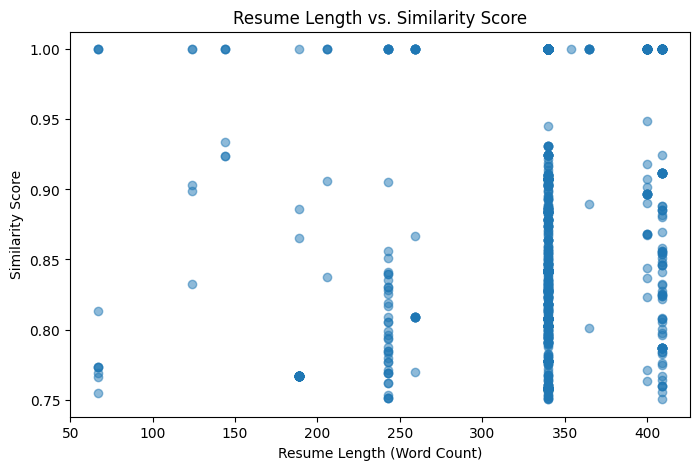

In [15]:
import matplotlib.pyplot as plt

# Create a resume length column
df["resume_length"] = df["job_description"].apply(lambda x: len(str(x).split()))  # Word count

# Scatter plot of resume length vs. similarity score
plt.figure(figsize=(8, 5))
plt.scatter(df["resume_length"], df["similarity_score"], alpha=0.5)
plt.xlabel("Resume Length (Word Count)")
plt.ylabel("Similarity Score")
plt.title("Resume Length vs. Similarity Score")
plt.show()


In [16]:
# Count how often each skill appears in the resumes
df_filtered["ability"].value_counts().head(10)


,count
ability,
Database Administration,103
Oracle Database Administration,99
Database Administrator,70
Database administration,48
Oracle Database Administrator,36
DBA,21
SQL Server Database Administration,19
Database,18
Database Design,15
